# Sentence-Window and Parent-Child — Small to Find, Big to Read

## What problem does this solve?

Small chunks find precisely; large chunks generate well. A chunk that contains exactly the sentence answering the question ranks first under cosine search, but the LLM gets one sentence and no context. A chunk that contains the answer plus three paragraphs of context generates a richer answer, but its embedding is diluted and it may not rank first.
Parent-child retrieval gives you both. Index small chunks for retrieval. When a small chunk is retrieved, return its bigger parent chunk to the generator. The retrieval score reflects the small unit; the generation context reflects the surrounding prose.

## Where it came from

Parent-child retrieval was shipped in LlamaIndex's `HierarchicalNodeParser` in mid-2023 and in LangChain's `ParentDocumentRetriever` shortly after. Neither paper coined the term; the technique was an obvious composition of small-window and big-window retrieval that emerged as developers iterated on RAG demos.
By 2026 it is one of the most quietly important patterns in production RAG: systems that look like "just RAG" are almost always doing some form of small-to-big. The pattern fits cleanly under reranking and adaptive layers, which is part of why it has stayed relevant for three years without significant updates.

## Where it fits in the RAG landscape

Sentence-window is a parent-child variant: children are single sentences, parents are 3-sentence neighbourhoods. Same idea, different aspect ratio.

Three cousins to know:

- **Parent-child (this recipe).** Two levels: child for retrieval, parent for generation.
- **RAPTOR (Recipe 10).** Many levels: leaves, summary, summary-of-summaries.
- **Document-summary routing (Recipe 11).** Top level is a per-document summary; bottom level is chunks within the chosen document.

Compose with everything: semantic chunks for the parent (Recipe 5), contextual headers on the parent (Recipe 7), propositions instead of sentences as children (Recipe 8). The cookbook's `cookbook.chunkers.parent_child` returns both lists; the rest is composition.

## When to use it (and when not to)

Use parent-child whenever your generated answers benefit from context that a small retrieval unit alone would lack. Open-ended Q&A, summarisation, technical explanation — all good fits, because the model needs surrounding paragraphs to produce a confident, complete answer.
Skip it when generation is one-token (classifier-style RAG) or single-sentence (extractive QA). The parent context is wasted because the model only needs the matched sentence to produce its output.
Skip it when the parent is too big for your generation budget. If your parent is 4000 tokens and you retrieve k=5, your prompt is 20k tokens before the question. Resize down or use sentence-window as the children to make room.

## The intuition

Three intuitions:

**Retrieval and generation want different chunk sizes.** They are competing constraints. Parent-child decouples them so each side can have what it wants — small for precision-of-ranking, big for richness-of-context.

**The parent doesn't need to be perfectly chosen.** A reasonable parent (the sentence's enclosing paragraph, or a 1000-token window centered on the matched child) is enough. You don't need to find the "right" parent — any parent that includes the child plus a few hundred tokens of surrounding context will do, because the generator can read past irrelevant material.

**Deduplication is essential.** When several children of the same parent get retrieved, you don't want to return the parent five times. Deduplicate by parent ID after collecting children; this is the only non-trivial piece of glue in the whole pattern.

## Architecture

```mermaid
flowchart TB
  D[Documents] --> P[Parent chunks<br/>~1000 tokens]
  P --> C[Child chunks<br/>~200 tokens]
  C --> S[(Vector store)]
  Q[Query] --> R[Retrieve top-N children]
  S --> R
  R --> DD[Dedupe by<br/>parent id]
  DD --> G[Return parents<br/>to generator]
```

## References

- 📚 [LlamaIndex HierarchicalNodeParser](https://developers.llamaindex.ai/python/framework-api-reference/llama_index/core/node_parser/HierarchicalNodeParser/) — Reference implementation.
- 📚 [LangChain ParentDocumentRetriever](https://python.langchain.com/docs/how_to/parent_document_retriever/) — The cousin implementation.
- 📚 [LlamaIndex small-to-big tutorial](https://developers.llamaindex.ai/python/examples/node_postprocessor/AutoMergingRetrieverDemo/) — Walk-through of the pattern.
- 📄 [Propositional chunking paper (Recipe 8)](https://arxiv.org/abs/2312.06648) — Alternative answer to the small-unit retrieval question.
- 📄 [RAPTOR (Recipe 10)](https://arxiv.org/abs/2401.18059) — A multi-level extension of parent-child.
- 📝 [Anthropic Contextual Retrieval](https://www.anthropic.com/news/contextual-retrieval) — Composes well with parent-child.

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Load the Rust book

Long-form technical prose is the natural home of parent-child. Chapters are long; a small chunk gives precise retrieval; the chapter context is what the LLM needs to answer well.

In [2]:
from cookbook.corpora import load_rust_book

docs = list(load_rust_book())[:10]
print(f'Loaded {len(docs)} chapters.')

Loaded 10 chapters.


### Step 2 — Build aligned children and parents

`cookbook.chunkers.parent_child` returns three things: children for retrieval, parents for generation, and a child-to-parent mapping.

In [3]:
from cookbook.chunkers import parent_child

children, parents, mapping = parent_child(docs, parent_tokens=900, child_tokens=180, overlap=24)
parents_by_id = {p.chunk_id: p for p in parents}
print(f'{len(children)} children -> {len(parents)} parents')

61 children -> 17 parents


### Step 3 — Index the children

Only the children get embedded and stored. Parents live in a Python dictionary keyed by ID.

In [4]:
from cookbook.stores import QdrantBackend

vectors = client.embed([c.text for c in children])
store = QdrantBackend('pc', dim=len(vectors[0]))
store.add([c.text for c in children], vectors, ids=[c.chunk_id for c in children])
print(f'Indexed {len(children)} children. Parents kept in memory.')

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Indexed 61 children. Parents kept in memory.


### Step 4 — Retrieve, then walk to parents

Retrieve children, look up their parents, deduplicate. The deduplication step matters: multiple children of the same parent are common.

In [5]:
def retrieve_parents(question: str, top_k: int = 4):
    qv = client.embed([question])[0]
    hits = store.search(qv, top_k=top_k * 3)
    seen, parent_ids = set(), []
    for h in hits:
        pid = mapping.get(h.doc_id)
        if pid and pid not in seen:
            seen.add(pid)
            parent_ids.append(pid)
        if len(parent_ids) >= top_k:
            break
    return [parents_by_id[i] for i in parent_ids]

for p in retrieve_parents('What is selective scan?'):
    print(f'  parent {p.chunk_id} ({len(p.text)} chars):')
    print(f'    {p.text[:200]}...')

  parent rust-book:ch07-00-managing-growing-projects-with-packages-crates-and-modules#fw0000 (2935 chars):
    <!-- Old headings. Do not remove or links may break. --> <a id="managing-growing-projects-with-packages-crates-and-modules"></a> # Packages, Crates, and Modules As you write large programs, organizing...
  parent rust-book:ch10-00-generics#fw0001 (52 chars):
    would we eliminate that duplication? Let’s find out!...
  parent rust-book:ch02-00-guessing-game-tutorial#fw0004 (5727 chars):
    the secret number. This is useful while we’re developing the program to be able to test it, but we’ll delete it from the final version. It’s not much of a game if the program prints the answer as soon...
  parent rust-book:ch02-00-guessing-game-tutorial#fw0000 (6074 chars):
    # Programming a Guessing Game Let’s jump into Rust by working through a hands-on project together! This chapter introduces you to a few common Rust concepts by showing you how to use them in a real pr...


### Step 5 — Wrap as `answer_question`

Standard contract. Generation uses the parents.

In [6]:
def answer_question(question: str, k: int = 3) -> tuple[str, list[str]]:
    parents = retrieve_parents(question, top_k=k)
    contexts = [p.text for p in parents]
    answer = client.chat(
        'Use these passages.\n' + '\n\n'.join(contexts) + f'\nQ: {question}\nA:'
    )
    return answer, contexts

ans, _ = answer_question('Walk through how the borrow checker reasons about overlapping references.')
print(ans)

The provided passages do not discuss how the borrow checker reasons about overlapping references. They cover the topics of ownership, generic types, traits, lifetimes, and error handling in Rust, but do not specifically address the borrow checker's reasoning about overlapping references.

However, I can provide a general overview of how the borrow checker works in Rust. The borrow checker is a key component of the Rust compiler that ensures memory safety by enforcing the rules of ownership and borrowing. When the borrow checker encounters a reference to a value, it checks whether the reference is valid and whether it overlaps with any other references to the same value.

Here's a high-level overview of how the borrow checker reasons about overlapping references:

1. **Reference creation**: When a reference is created, the borrow checker checks whether the reference is valid. This includes checking whether the referenced value is alive and whether the reference is properly scoped.
2. **

## Look Inside

### Inspect — child vs parent length

Quick visual: children are short, parents are long. The asymmetry is the whole point.

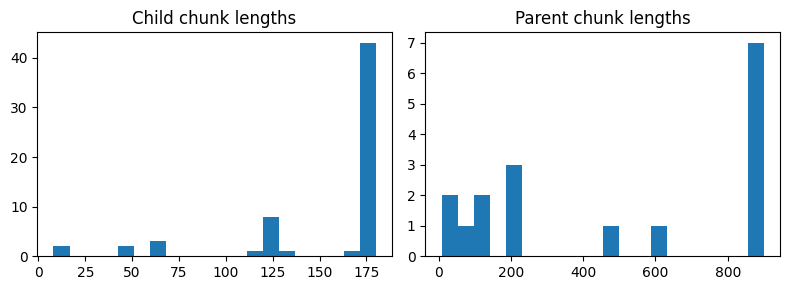

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist([len(c.text.split()) for c in children], bins=20)
axes[0].set_title('Child chunk lengths')
axes[1].hist([len(p.text.split()) for p in parents], bins=20)
axes[1].set_title('Parent chunk lengths')
plt.tight_layout()
plt.show()

### Inspect — fan-in: how many children per parent?

If parents have 1 child each, there's no deduplication work to do — but you probably could have used the parent directly. If parents have many children, deduplication matters a lot.

In [8]:
from collections import Counter
fan_in = Counter(mapping.values())
print(f'Average children per parent: {sum(fan_in.values()) / max(1, len(fan_in)):.1f}')
print(f'Max children per parent: {max(fan_in.values())}')

Average children per parent: 3.6
Max children per parent: 6


### Inspect — top-k matched children for one query

Look at the children that win retrieval. Do they all live in the same parent? Or are they spread across parents?

In [9]:
q = 'How does the borrow checker reason about overlapping references?'
qv = client.embed([q])[0]
hits = store.search(qv, top_k=10)
for h in hits:
    pid = mapping.get(h.doc_id, '?')
    print(f'  score={h.score:.3f}  parent={pid}  child={h.doc_id}')

  score=0.607  parent=rust-book:ch04-00-understanding-ownership#fw0000  child=rust-book:ch04-00-understanding-ownership#fw0000#c000
  score=0.557  parent=rust-book:ch10-00-generics#fw0000  child=rust-book:ch10-00-generics#fw0000#c001
  score=0.555  parent=rust-book:ch09-00-error-handling#fw0000  child=rust-book:ch09-00-error-handling#fw0000#c000
  score=0.547  parent=rust-book:ch10-00-generics#fw0000  child=rust-book:ch10-00-generics#fw0000#c000
  score=0.511  parent=rust-book:ch02-00-guessing-game-tutorial#fw0006  child=rust-book:ch02-00-guessing-game-tutorial#fw0006#c003
  score=0.506  parent=rust-book:ch10-00-generics#fw0001  child=rust-book:ch10-00-generics#fw0001#c000
  score=0.504  parent=rust-book:ch07-00-managing-growing-projects-with-packages-crates-and-modules#fw0000  child=rust-book:ch07-00-managing-growing-projects-with-packages-crates-and-modules#fw0000#c001
  score=0.499  parent=rust-book:ch08-00-common-collections#fw0000  child=rust-book:ch08-00-common-collections#fw0000

### Inspect — recall@5 with vs without parent walk

Loose recall proxy. Children-only retrieval should beat parents-only for sharpness, but the difference is small on prose corpora.

In [10]:
from cookbook.corpora import load_eval_questions
qs = [q for q in load_eval_questions() if q['corpus'] == 'rust-book'][:8]
def recall(retr_fn):
    hits = 0
    for q in qs:
        out = retr_fn(q['question'])
        gold = [w.lower() for w in q['answer'].split() if len(w) >= 4]
        if any(any(w[:6] in t.lower() for w in gold) for t in out):
            hits += 1
    return hits / max(1, len(qs))

def via_children(q):
    qv = client.embed([q])[0]
    return [h.text for h in store.search(qv, top_k=5)]
def via_parents(q):
    return [p.text for p in retrieve_parents(q, top_k=3)]
print(f'children-only recall@5 = {recall(via_children):.2f}')
print(f'parent-walk   recall@5 = {recall(via_parents):.2f}')

children-only recall@5 = 1.00


parent-walk   recall@5 = 1.00


## Run It

End-to-end on a question that benefits from parent context.

In [11]:
ans, ctxs = answer_question('When should I prefer Arc over Rc, and what guarantees do I lose if I switch?')
print('=== Parent-child answer ===')
print(ans)

=== Parent-child answer ===
The provided passages do not contain information about `Arc` and `Rc`, or when to prefer one over the other. The passages discuss ownership, error handling, and generic types, traits, and lifetimes in Rust, but do not mention these specific types.

However, I can provide a general answer to this question. In Rust, `Rc` (Reference Counting) and `Arc` (Atomic Reference Counting) are both used for reference counting, but they have different use cases.

`Rc` is used for single-threaded applications, where the reference count is not thread-safe. It is faster and more lightweight than `Arc`, but it is not safe to share `Rc` instances across threads.

`Arc`, on the other hand, is used for multi-threaded applications, where the reference count needs to be thread-safe. It uses atomic operations to update the reference count, making it safe to share `Arc` instances across threads.

If you switch from `Rc` to `Arc`, you gain thread-safety, but you may lose some perform

## Side by Side: Vanilla Baseline vs This Technique

Vanilla baseline (flat fixed-window) vs parent-child. The interesting case is a question where vanilla finds the right paragraph but the answer needs surrounding paragraphs to write well.

In [12]:
from cookbook.baselines import vanilla_pipeline

q = 'When should I prefer Arc over Rc, and what guarantees do I lose if I switch?'
base = vanilla_pipeline(q, corpus='rust-book', top_k=5)
ours_a, ours_c = answer_question(q)

import pandas as pd
pd.DataFrame([
    {'pipeline': 'vanilla', 'avg_ctx_chars': sum(len(c) for c in base.contexts) // max(1, len(base.contexts))},
    {'pipeline': 'parent-child', 'avg_ctx_chars': sum(len(c) for c in ours_c) // max(1, len(ours_c))},
])

,pipeline,avg_ctx_chars
0,vanilla,1446
1,parent-child,2462


## Knobs to Turn

Five knobs in priority order:

1. **Parent and child sizes.** Defaults of 900 / 180 are reasonable for prose. For code or tables, both should be bigger. For short factual content, both should be smaller. The ratio matters as much as absolute sizes.
2. **Child-to-parent fan-in.** A parent with 50 children is fine but means deduplication eats latency. Trim by widening children or narrowing parents.
3. **Number of children to over-retrieve.** Our function retrieves `k*3` children to dedupe down to `k` parents. Higher multipliers improve recall at the cost of one more embedding lookup.
4. **Reranker on children before walking.** Without reranking, noisy children promote noisy parents. A cross-encoder rerank (Recipe 22) on the child list before walking is the single biggest quality lift.
5. **Parent boundary alignment.** Semantic chunking for the parents (Recipe 5) avoids the mid-paragraph parent problem and improves generation quality more than any other change.

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [13]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'rust-book']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,What is ownership in Rust?,A set of rules governing how memory is managed...,"Ownership is Rust's most unique feature, which...",3
1,What does the borrow checker do?,It statically enforces that references obey th...,The passage doesn't explicitly state what the ...,3
2,What is the difference between String and &str?,"`String` is an owned, heap-allocated, growable...",The text does not explicitly explain the diffe...,3
3,Describe how match is exhaustive in Rust.,The compiler requires `match` arms to cover ev...,"In Rust, `match` is exhaustive, meaning that i...",3
4,What is a trait?,A trait is a named set of methods that types c...,A trait is a way to define behavior in a gener...,3


## Closing Thoughts

Three failure modes:

- **Skinny prompts.** With k=3 parents at 900 tokens each, you have 2700 tokens of context per query. If your model supports it, great; if it caps at 4k, you have no headroom for instructions.
- **Mismatched parent boundaries.** A child whose parent ends mid-paragraph still carries a half-thought to the LLM. Use semantic chunking for the parents to avoid this.
- **No reranking before parent walk.** If you walk parents from the top-N children unranked, noisy children promote noisy parents. Insert a reranker (Recipe 22) on the children before walking.

Compose with semantic boundary chunking (Recipe 5) for the parents, contextual headers (Recipe 7) on the parents, and reranking (Recipe 22) on the children. That stack is what production RAG looks like in 2026.